# 📐 Vectors and Dot Products — the Geometry Behind the Algebra

**Linear Algebra and Analytic Geometry** · TSIW, ESMAD — Polytechnic of Porto
Lesson notebook **01 of 08** · Library: [`linalg_utils`](../packages/python/src/linalg_utils)

> **Assignment alignment** — supplemental notebook (not part of the graded assignments), but the
> vector toolkit built here is used everywhere else in the course.

---

Vectors are the atoms of linear algebra. Before we can talk about matrices, systems, or
decompositions, we need a solid, *visual* grip on four ideas:

1. a vector is **an arrow** (direction + length), not just a list of numbers;
2. the **dot product** measures how much two vectors point the same way;
3. **norms** turn vectors into lengths and distances;
4. **projection** is the "shadow" of one vector on another — the single most reused
   construction in this course (least squares, QR, PCA all reduce to it).

## Table of contents

1. [Setup](#setup)
2. [Vectors as arrows](#arrows)
3. [Vector arithmetic](#arithmetic)
4. [The dot product: two definitions, one number](#dot)
5. [Norms and distances](#norms)
6. [Angles between vectors](#angles)
7. [Projection: casting shadows](#projection)
8. [Sanity checks: classic inequalities](#inequalities)
9. [Application: cosine similarity](#cosine)
10. [Key takeaways](#takeaways)

<a id="setup"></a>
## 1 · Setup

We import NumPy, Matplotlib, and the course library `linalg_utils`, and define one consistent,
colorblind-safe figure style used across the whole notebook series.

In [1]:
# ── Setup: imports, course library, and a consistent figure style ──────────
import sys
from pathlib import Path

# Make the course library importable straight from a repo clone
# (equivalent to `poetry install` inside packages/python).
_SRC = (Path.cwd().parent / "packages" / "python" / "src").resolve()
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import matplotlib.pyplot as plt

# Colorblind-safe categorical palette, used in fixed order across the series.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor":   BASE,
    "axes.labelcolor":  INK,
    "axes.titlecolor":  INK,
    "axes.titleweight": "bold",
    "axes.grid":        True,
    "grid.color":       GRID,
    "grid.linewidth":   0.8,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "axes.prop_cycle":  plt.cycler(color=PALETTE),
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.frameon":   False,
    "figure.dpi":       110,
})
np.set_printoptions(precision=4, suppress=True)

import linalg_utils
print("NumPy", np.__version__, "| linalg_utils loaded from", Path(linalg_utils.__file__).parent)

NumPy 2.3.5 | linalg_utils loaded from C:\Users\diogo\work_code\linear-algebra-with-python\packages\python\src\linalg_utils


<a id="arrows"></a>
## 2 · Vectors as arrows

A vector $\mathbf{v} = (v_1, v_2)$ lives in $\mathbb{R}^2$ as **an arrow from the origin to the
point $(v_1, v_2)$**. Everything in this notebook — lengths, angles, shadows — is a statement
about arrows first and about coordinates second.

Throughout the notebook we will work with two running examples:

$$\mathbf{u} = \begin{pmatrix} 1 \\ 2 \end{pmatrix}, \qquad
\mathbf{v} = \begin{pmatrix} 3 \\ 1 \end{pmatrix}.$$

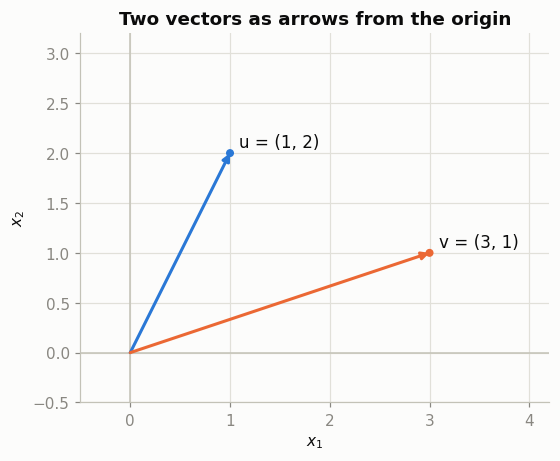

In [2]:
u = np.array([1.0, 2.0])
v = np.array([3.0, 1.0])


def draw_vector(ax, vec, *, color, label, origin=(0.0, 0.0), ls="-"):
    """Draw `vec` as an arrow starting at `origin`."""
    ax.annotate(
        "", xy=(origin[0] + vec[0], origin[1] + vec[1]), xytext=origin,
        arrowprops=dict(arrowstyle="-|>", color=color, lw=2, linestyle=ls,
                        shrinkA=0, shrinkB=0),
    )
    ax.annotate(label, xy=(origin[0] + vec[0], origin[1] + vec[1]),
                xytext=(6, 4), textcoords="offset points",
                color=INK, fontsize=11)


fig, ax = plt.subplots(figsize=(5.5, 5))
draw_vector(ax, u, color=PALETTE[0], label="u = (1, 2)")
draw_vector(ax, v, color=PALETTE[1], label="v = (3, 1)")
ax.scatter(*np.column_stack([u, v]), s=18, color=[PALETTE[0], PALETTE[1]], zorder=3)
ax.set_xlim(-0.5, 4.2)
ax.set_ylim(-0.5, 3.2)
ax.set_aspect("equal")
ax.axhline(0, color=BASE, lw=1)
ax.axvline(0, color=BASE, lw=1)
ax.set_title("Two vectors as arrows from the origin")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()

<a id="arithmetic"></a>
## 3 · Vector arithmetic

Two operations define a vector space:

- **Addition** — place $\mathbf{v}$'s tail at $\mathbf{u}$'s head: the sum is the diagonal of
  the parallelogram (the *parallelogram rule*).
- **Scalar multiplication** — $c\,\mathbf{u}$ stretches the arrow by $|c|$
  (and flips it when $c < 0$). All multiples of $\mathbf{u}$ trace out a **line through the
  origin**: the simplest subspace.

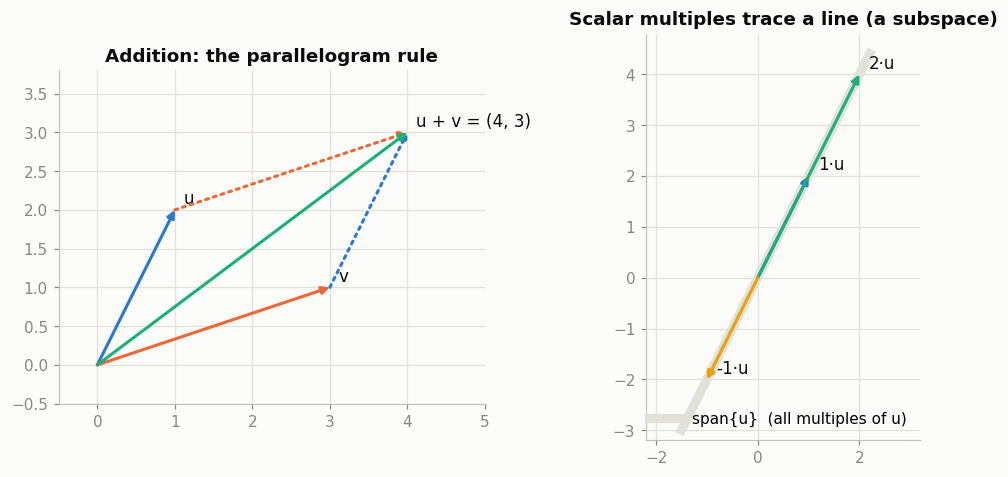

u + v      = [4. 3.]
2u - 3v    = [-7.  1.]


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Left: parallelogram rule for u + v
ax = axes[0]
draw_vector(ax, u, color=PALETTE[0], label="u")
draw_vector(ax, v, color=PALETTE[1], label="v")
draw_vector(ax, v, origin=u, color=PALETTE[1], label="", ls=":")
draw_vector(ax, u, origin=v, color=PALETTE[0], label="", ls=":")
draw_vector(ax, u + v, color=PALETTE[2], label="u + v = (4, 3)")
ax.set_xlim(-0.5, 5.0)
ax.set_ylim(-0.5, 3.8)
ax.set_aspect("equal")
ax.set_title("Addition: the parallelogram rule")

# Right: scalar multiples of u sweep out a line
ax = axes[1]
ts = np.linspace(-1.5, 2.2, 100)
line = np.outer(ts, u)
ax.plot(line[:, 0], line[:, 1], color=GRID, lw=6, zorder=0,
        label="span{u}  (all multiples of u)")
for c, colr in [(1.0, PALETTE[0]), (2.0, PALETTE[2]), (-1.0, PALETTE[3])]:
    draw_vector(ax, c * u, color=colr, label=f"{c:g}·u")
ax.set_xlim(-2.2, 3.2)
ax.set_ylim(-3.2, 4.8)
ax.set_aspect("equal")
ax.set_title("Scalar multiples trace a line (a subspace)")
ax.legend(loc="lower right")
plt.show()

print("u + v      =", u + v)
print("2u - 3v    =", 2 * u - 3 * v)

<a id="dot"></a>
## 4 · The dot product: two definitions, one number

The dot product has an **algebraic** definition and a **geometric** one:

$$\mathbf{u} \cdot \mathbf{v}
   \;=\; \underbrace{u_1 v_1 + u_2 v_2}_{\text{algebra: multiply \& add}}
   \;=\; \underbrace{\lVert\mathbf{u}\rVert\,\lVert\mathbf{v}\rVert \cos\theta}_{\text{geometry: lengths \& angle}}$$

The same number answers a geometric question: **how aligned are the two arrows?**

| sign of $\mathbf{u}\cdot\mathbf{v}$ | angle $\theta$ | reading |
|---|---|---|
| $> 0$ | $\theta < 90^\circ$ | broadly pointing the *same* way |
| $= 0$ | $\theta = 90^\circ$ | **orthogonal** (perpendicular) |
| $< 0$ | $\theta > 90^\circ$ | broadly pointing in *opposite* ways |

The course library implements this as `linalg_utils.vectors.dot`. We verify both definitions
give the same number, and check the sign rule against three hand-picked vectors.

In [4]:
from linalg_utils.vectors import dot, norm, angle, projection

# Algebraic and geometric definitions must agree.
algebraic = dot(u, v)                                  # u1*v1 + u2*v2
theta = angle(u, v)                                    # radians
geometric = norm(u) * norm(v) * np.cos(theta)

print(f"algebraic  u·v = {algebraic:.6f}")
print(f"geometric  u·v = {geometric:.6f}   (‖u‖‖v‖cosθ)")

# Sign rule: same side, perpendicular, opposite side.
w_same, w_perp, w_opp = np.array([2.0, 1.0]), np.array([-2.0, 1.0]), np.array([-1.0, -2.0])
for name, w in [("same-ish", w_same), ("perpendicular", w_perp), ("opposite-ish", w_opp)]:
    print(f"u · {name:>13s} vector {w} → {dot(u, w):+.1f}")

algebraic  u·v = 5.000000
geometric  u·v = 5.000000   (‖u‖‖v‖cosθ)
u ·      same-ish vector [2. 1.] → +4.0
u · perpendicular vector [-2.  1.] → +0.0
u ·  opposite-ish vector [-1. -2.] → -5.0


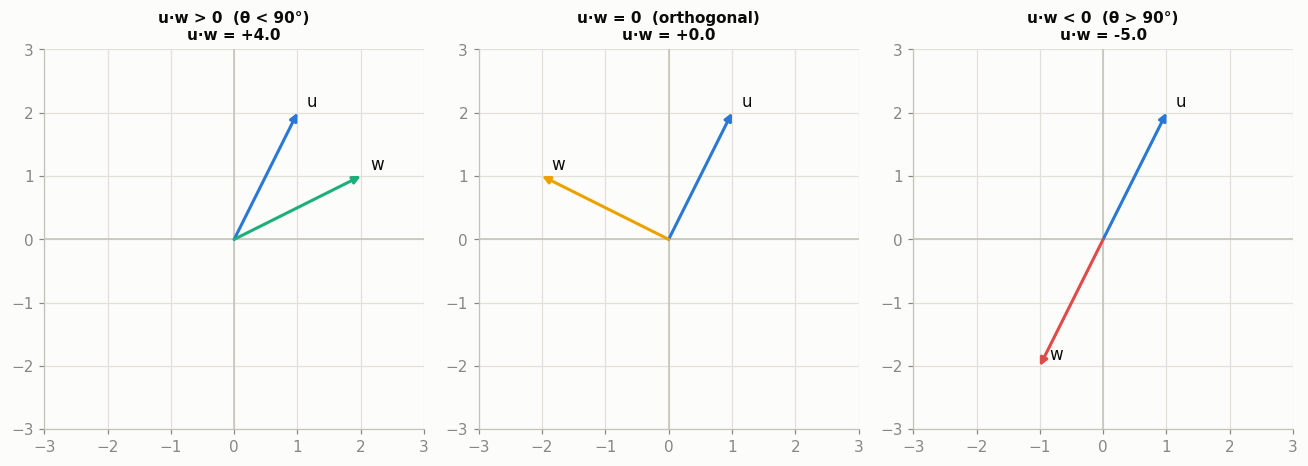

In [5]:
# Visualize the sign rule: u fixed, three companions with positive / zero / negative dot.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
cases = [("u·w > 0  (θ < 90°)", w_same, PALETTE[2]),
         ("u·w = 0  (orthogonal)", w_perp, PALETTE[3]),
         ("u·w < 0  (θ > 90°)", w_opp, PALETTE[7])]
for ax, (title, w, colr) in zip(axes, cases):
    draw_vector(ax, u, color=PALETTE[0], label="u")
    draw_vector(ax, w, color=colr, label="w")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.axhline(0, color=BASE, lw=1)
    ax.axvline(0, color=BASE, lw=1)
    ax.set_title(f"{title}\nu·w = {dot(u, w):+.1f}", fontsize=10)
plt.tight_layout()
plt.show()

<a id="norms"></a>
## 5 · Norms and distances

The **Euclidean norm** is the dot product of a vector with itself, square-rooted:

$$\lVert\mathbf{v}\rVert = \sqrt{\mathbf{v}\cdot\mathbf{v}} = \sqrt{v_1^2 + v_2^2}
\qquad\text{(Pythagoras, in disguise)}$$

Norms immediately give **distances**: the distance between two points is the norm of their
difference, $d(\mathbf{u},\mathbf{v}) = \lVert\mathbf{u}-\mathbf{v}\rVert$. And dividing a
vector by its norm produces a **unit vector** — pure direction, length 1.

‖u‖              = 2.236068   (√(1² + 2²) = √5 ≈ 2.236068)
‖v‖              = 3.162278
distance ‖u − v‖ = 2.236068
û = u/‖u‖        = [0.4472 0.8944]   with ‖û‖ = 1.000000


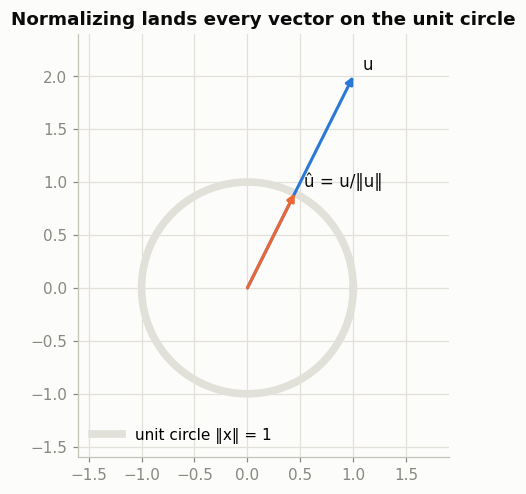

In [6]:
print(f"‖u‖              = {norm(u):.6f}   (√(1² + 2²) = √5 ≈ {np.sqrt(5):.6f})")
print(f"‖v‖              = {norm(v):.6f}")
print(f"distance ‖u − v‖ = {norm(u - v):.6f}")

u_hat = u / norm(u)                       # unit vector: direction of u
print(f"û = u/‖u‖        = {u_hat}   with ‖û‖ = {norm(u_hat):.6f}")

# The unit circle is exactly the set of vectors with norm 1.
theta_grid = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(np.cos(theta_grid), np.sin(theta_grid), color=GRID, lw=5, zorder=0,
        label="unit circle ‖x‖ = 1")
draw_vector(ax, u, color=PALETTE[0], label="u")
draw_vector(ax, u_hat, color=PALETTE[1], label="û = u/‖u‖")
ax.set_xlim(-1.6, 1.9)
ax.set_ylim(-1.6, 2.4)
ax.set_aspect("equal")
ax.set_title("Normalizing lands every vector on the unit circle")
ax.legend(loc="lower left")
plt.show()

<a id="angles"></a>
## 6 · Angles between vectors

Rearranging the geometric definition isolates the angle:

$$\theta = \arccos\!\left(\frac{\mathbf{u}\cdot\mathbf{v}}
{\lVert\mathbf{u}\rVert\,\lVert\mathbf{v}\rVert}\right) \in [0, \pi].$$

`linalg_utils.vectors.angle` wraps exactly this formula (with the argument clipped to
$[-1, 1]$ so floating-point noise can never push `arccos` out of its domain).

In [7]:
pairs = [
    ("u, v",                u, v),
    ("u, 3u (parallel)",    u, 3 * u),
    ("u, −u (antiparallel)", u, -u),
    ("e₁, e₂ (orthogonal)", np.array([1.0, 0.0]), np.array([0.0, 1.0])),
]
print(f"{'pair':<22s} {'radians':>9s} {'degrees':>9s}")
for name, a, b in pairs:
    th = angle(a, b)
    print(f"{name:<22s} {th:>9.4f} {np.degrees(th):>8.2f}°")

pair                     radians   degrees
u, v                      0.7854    45.00°
u, 3u (parallel)          0.0000     0.00°
u, −u (antiparallel)      3.1416   180.00°
e₁, e₂ (orthogonal)       1.5708    90.00°


<a id="projection"></a>
## 7 · Projection: casting shadows

The **orthogonal projection** of $\mathbf{u}$ onto $\mathbf{v}$ is the part of $\mathbf{u}$
that points along $\mathbf{v}$ — its *shadow* under light shining perpendicular to $\mathbf{v}$:

$$\operatorname{proj}_{\mathbf{v}}\mathbf{u}
   = \frac{\mathbf{u}\cdot\mathbf{v}}{\mathbf{v}\cdot\mathbf{v}}\,\mathbf{v}.$$

The leftover $\mathbf{u} - \operatorname{proj}_{\mathbf{v}}\mathbf{u}$ is **orthogonal** to
$\mathbf{v}$ — that is the defining property, and we verify it numerically. Keep this picture
in mind: least squares (notebook 04), QR (notebook 05), and PCA (notebook 07) are all
"project, then look at what is left over".

proj_v(u)          = [1.5 0.5]
residual u − p     = [-0.5  1.5]
r · v              = +0.00e+00   (orthogonal ⇒ ≈ 0)
‖u‖² = ‖p‖² + ‖r‖²:  5.0000 = 2.5000 + 2.5000


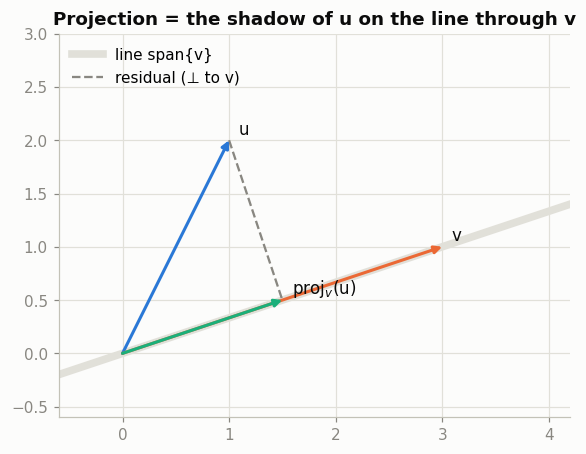

In [8]:
p = projection(u, v)          # shadow of u along v
r = u - p                     # residual: what projection leaves behind

print(f"proj_v(u)          = {p}")
print(f"residual u − p     = {r}")
print(f"r · v              = {dot(r, v):+.2e}   (orthogonal ⇒ ≈ 0)")
print(f"‖u‖² = ‖p‖² + ‖r‖²:  {norm(u)**2:.4f} = {norm(p)**2:.4f} + {norm(r)**2:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ts = np.linspace(-0.3, 1.4, 50)
span = np.outer(ts, v)
ax.plot(span[:, 0], span[:, 1], color=GRID, lw=5, zorder=0, label="line span{v}")
draw_vector(ax, u, color=PALETTE[0], label="u")
draw_vector(ax, v, color=PALETTE[1], label="v")
draw_vector(ax, p, color=PALETTE[2], label="proj$_v$(u)")
# dashed drop from u down to its shadow
ax.plot([u[0], p[0]], [u[1], p[1]], ls="--", color=MUTED, lw=1.5,
        label="residual (⊥ to v)")
ax.set_xlim(-0.6, 4.2)
ax.set_ylim(-0.6, 3.0)
ax.set_aspect("equal")
ax.set_title("Projection = the shadow of u on the line through v")
ax.legend(loc="upper left")
plt.show()

<a id="inequalities"></a>
## 8 · Sanity checks: classic inequalities

Two famous inequalities bound how dot products and norms interact. We stress-test both on
10 000 random vector pairs — a habit worth copying: *when you code linear algebra, verify
identities numerically.*

- **Cauchy–Schwarz:** $|\mathbf{u}\cdot\mathbf{v}| \le \lVert\mathbf{u}\rVert\,\lVert\mathbf{v}\rVert$
  (equality ⟺ the vectors are parallel);
- **Triangle inequality:** $\lVert\mathbf{u}+\mathbf{v}\rVert \le \lVert\mathbf{u}\rVert + \lVert\mathbf{v}\rVert$
  (a detour is never shorter than the straight path).

Cauchy–Schwarz holds for all pairs: True
Triangle inequality holds for all pairs: True
tightest Cauchy–Schwarz ratio observed: 0.999857  (1 ⇔ parallel)


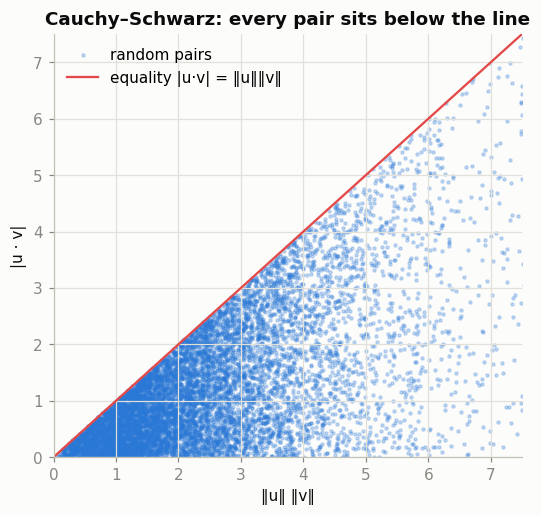

In [9]:
rng = np.random.default_rng(7)
U = rng.normal(size=(10_000, 3))          # random 3-D vectors this time
V = rng.normal(size=(10_000, 3))

dots  = np.abs(np.einsum("ij,ij->i", U, V))
prods = np.linalg.norm(U, axis=1) * np.linalg.norm(V, axis=1)
tri_l = np.linalg.norm(U + V, axis=1)
tri_r = np.linalg.norm(U, axis=1) + np.linalg.norm(V, axis=1)

print(f"Cauchy–Schwarz holds for all pairs: {bool(np.all(dots <= prods + 1e-12))}")
print(f"Triangle inequality holds for all pairs: {bool(np.all(tri_l <= tri_r + 1e-12))}")
print(f"tightest Cauchy–Schwarz ratio observed: {np.max(dots / prods):.6f}  (1 ⇔ parallel)")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(prods, dots, s=4, alpha=0.25, color=PALETTE[0], label="random pairs")
lim = np.percentile(prods, 99)
ax.plot([0, lim], [0, lim], color=PALETTE[7], lw=1.5, label="equality |u·v| = ‖u‖‖v‖")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("‖u‖ ‖v‖")
ax.set_ylabel("|u · v|")
ax.set_title("Cauchy–Schwarz: every pair sits below the line")
ax.legend()
plt.show()

<a id="cosine"></a>
## 9 · Application: cosine similarity

The quantity $\cos\theta = \dfrac{\mathbf{u}\cdot\mathbf{v}}{\lVert\mathbf{u}\rVert\lVert\mathbf{v}\rVert}$
is used throughout data science as **cosine similarity**: it compares *directions* while
ignoring magnitudes. A classic use is comparing texts by word-count vectors — a long document
and a short one about the same topic point the *same way* even though their counts differ.

Below, four tiny "documents" are described by counts of the words
*(matrix, vector, guitar, chord)*.

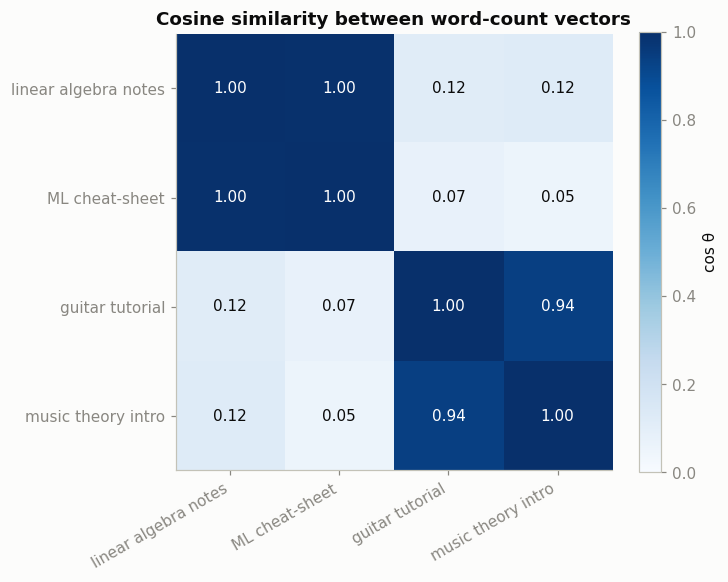

The two math texts align (cos ≈ 1.00); math vs. music is nearly orthogonal (cos ≈ 0.12).


In [10]:
vocab = ["matrix", "vector", "guitar", "chord"]
docs = {
    "linear algebra notes": np.array([8.0, 10.0, 0.0, 1.0]),
    "ML cheat-sheet":       np.array([5.0,  7.0, 0.0, 0.0]),
    "guitar tutorial":      np.array([0.0,  1.0, 9.0, 7.0]),
    "music theory intro":   np.array([1.0,  0.0, 6.0, 9.0]),
}

names = list(docs)
S = np.zeros((len(names), len(names)))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        S[i, j] = dot(docs[a], docs[b]) / (norm(docs[a]) * norm(docs[b]))

fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(S, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(names)), names, rotation=30, ha="right")
ax.set_yticks(range(len(names)), names)
ax.grid(False)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{S[i, j]:.2f}", ha="center", va="center",
                color="white" if S[i, j] > 0.6 else INK, fontsize=10)
ax.set_title("Cosine similarity between word-count vectors")
fig.colorbar(im, ax=ax, label="cos θ")
plt.show()

print("The two math texts align (cos ≈ %.2f); math vs. music is nearly orthogonal (cos ≈ %.2f)."
      % (S[0, 1], S[0, 2]))

<a id="takeaways"></a>
## 10 · Key takeaways

| Concept | Formula | Geometric meaning |
|---|---|---|
| Dot product | $u_1v_1 + u_2v_2 = \lVert\mathbf{u}\rVert\lVert\mathbf{v}\rVert\cos\theta$ | alignment of two arrows |
| Norm | $\sqrt{\mathbf{v}\cdot\mathbf{v}}$ | length of the arrow |
| Angle | $\arccos\big(\mathbf{u}\cdot\mathbf{v} / \lVert\mathbf{u}\rVert\lVert\mathbf{v}\rVert\big)$ | opening between arrows |
| Projection | $\frac{\mathbf{u}\cdot\mathbf{v}}{\mathbf{v}\cdot\mathbf{v}}\mathbf{v}$ | shadow of $\mathbf{u}$ on $\mathbf{v}$ |

- The **sign** of the dot product already tells a story: same side, perpendicular, opposite side.
- **Projection splits any vector** into a part along a direction and a part orthogonal to it —
  with $\lVert\mathbf{u}\rVert^2 = \lVert\mathbf{p}\rVert^2 + \lVert\mathbf{r}\rVert^2$ (Pythagoras again).
- Identities like Cauchy–Schwarz make excellent **numerical sanity checks** for your code.

**Next:** [02 — Matrices and linear maps](02_matrices_and_linear_maps.ipynb), where whole
*collections* of vectors move at once.